# HW17: Recommender systems

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from math import sqrt

In [2]:
from numba import cuda

USE_64 = True

if USE_64:
    bits = 64
    np_type = np.float64
else:
    bits = 32
    np_type = np.float32

In [3]:
%load_ext pycodestyle_magic

## Import data

In [4]:
r_df = pd.read_csv('data/ratings_small.csv')

In [5]:
meta_df = pd.read_csv('data/movies_metadata.csv', low_memory=False)

In [6]:
r_df.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [7]:
r_df.shape

(100004, 4)

In [8]:
r_df['movieId'].unique().shape

(9066,)

In [9]:
meta_df.head(2)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0


In [10]:
links_df = pd.read_csv('data/links.csv')

In [11]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [12]:
links_dict = pd.Series(links_df['imdbId'].values,index=links_df['movieId']).to_dict()

Figuring out the indexing:

In [13]:
r_df['imdb_id'] = r_df['movieId'].replace(links_dict)

In [14]:
r_df.shape

(100004, 5)

Cleaning out the meta_df before merging:

In [15]:
meta_df = meta_df.dropna(subset=['imdb_id'])

In [16]:
meta_df.loc[:, 'imdb_id'] = meta_df['imdb_id'].str.\
            slice(start=2).apply(lambda x: (-1) if x=='' else x).astype('int')

Merging the dataframes:

In [17]:
df = r_df.merge(meta_df, on='imdb_id')

In [18]:
df.shape

(99781, 28)

Getting rid of the extra columns:

In [19]:
df = df[['userId', 'rating', 'title']]

In [20]:
df.head()

,userId,rating,title
0,1,2.5,Dangerous Minds
1,7,3.0,Dangerous Minds
2,31,4.0,Dangerous Minds
3,32,4.0,Dangerous Minds
4,36,3.0,Dangerous Minds


Getting rid of the duplicate entries for the same users:

In [21]:
df = df.drop_duplicates(['userId','title'])

In [22]:
gr = df.groupby('userId')
gr_m = df.groupby('title')
val_array = df.values

## Model

### Similarity metrics

Based on Euclidian distance

In [23]:
def sim_dist(group, id1, id2, is_m=False):

    if not is_m:
        col = 2
    else:
        col = 0

    series1 = group.get_group(id1).values
    series2 = group.get_group(id2).values

    set_int = np.intersect1d(series1[:, col], series2[:, col])

    slice1 = series1[np.isin(series1[:, col], set_int), :]
    slice2 = series2[np.isin(series2[:, col], set_int), :]

    sum_of_sq = np.sum((slice1[:, 1]-slice2[:, 1])**2)

    if sum_of_sq == 0:
        return 0
    else:
        return 1/(1+sum_of_sq)

In [24]:
sim_dist(gr, 2, 3)

0.09523809523809523

In [25]:
sim_dist(gr_m, 'Dangerous Minds', 'Dumbo', is_m=True)

0.125

Based on Pearson correlation coefficient

In [26]:
def corr_coef(group, id1, id2, is_m=False):

    if not is_m:
        col = 2
    else:
        col = 0

    series1 = group.get_group(id1).values
    series2 = group.get_group(id2).values

    set_int = np.intersect1d(series1[:, col], series2[:, col])

    slice1 = series1[np.isin(series1[:, col], set_int), 1]
    slice2 = series2[np.isin(series2[:, col], set_int), 1]

    n = slice1.shape[0]
    if n == 0:
        return 0
    sum1 = np.sum(slice1)
    sum1sq = np.sum(slice1**2)
    sum2 = np.sum(slice2)
    sum2sq = np.sum(slice2**2)
    sum12 = np.sum(slice1*slice2)

    num = sum12 - (sum1 * sum2 / n)
    den = np.sqrt((sum1sq - (sum1**2) / n) * (sum2sq - (sum2**2) / n))

    if den == 0:
        return 0.0

    return num / den

In [27]:
corr_coef(gr, 2, 13)

-0.1057361065275362

In [28]:
corr_coef(gr_m, 'Dangerous Minds', 'Dumbo', is_m=True)

-0.5516772843673704

## Item-based collaborative filtering

### Defining helper functions to calculate similarity distances using GPU

Based on https://stackoverflow.com/questions/46655878/how-to-calculate-pairwise-distance-matrix-on-the-gpu?rq=1

In [29]:
@cuda.jit("void(float{}[:, :], float{}[:, :])".format(bits, bits))
def distance_matrix(mat, out):
    m = mat.shape[0]
    n = mat.shape[1]
    i, j = cuda.grid(2)
    d = 0
    flag = False
    if i < m and j < m:
        for k in range(n):
            coef = (mat[i, k] != 0) & (mat[j, k] != 0)
            if coef:
                flag = True
            tmp = (mat[i, k] - mat[j, k]) * coef
            d += tmp * tmp
        if flag:
            out[i, j] = 1 / (1 + d)
        else:
            out[i, j] = 0


def gpu_dist_matrix(mat):

    rows = mat.shape[0]

    block_dim = (16, 16)
    grid_dim = (int(rows/block_dim[0] + 1), int(rows/block_dim[1] + 1))

    stream = cuda.stream()
    mat2 = cuda.to_device(np.asarray(mat, dtype=np_type), stream=stream)
    out2 = cuda.device_array((rows, rows))
    distance_matrix[grid_dim, block_dim](mat2, out2)
    out = out2.copy_to_host(stream=stream)

    return out

### Defining the function returning a dataframe of all the movie similarities

In [30]:
def calc_similar_items(dataframe, similarity='l2'):
    group = dataframe.groupby('title')
    t_arr = group.apply(lambda x: x.values).values
    movie_names = list(group.groups.keys())

    movie_vecs = np.zeros((dataframe['title'].unique().shape[0],
                           dataframe['userId'].unique().shape[0]))
    # filling in the rating vectors for all the user-title pairs
    # with zero padding
    for i, t in enumerate(t_arr):
        t_idx = t[:, 0].astype('int')-1
        t_val = t[:, 1]
        movie_vecs[i][t_idx] = t_val

    if similarity == 'l2':
        sim_distances = gpu_dist_matrix(movie_vecs)
        return pd.DataFrame(sim_distances, index=movie_names,
                            columns=movie_names)
    elif similarity == 'pearson':
        mv_df = pd.DataFrame(movie_vecs.T, columns=movie_names)
        corr_df = mv_df[~mv_df.eq(0)].corr().fillna(0)
        return corr_df

In [31]:
%%time
#'l2' takes about 12 seconds to calculate, 'pearson' takes around 30
sim_dist_pearson = calc_similar_items(df, 'pearson')

CPU times: user 32.2 s, sys: 43.7 ms, total: 32.2 s
Wall time: 31.5 s


Checking if its calculating reasonable values:

In [32]:
sim_dist_pearson.loc['Dangerous Minds', 'Dumbo'] == \
    corr_coef(gr_m, 'Dangerous Minds', 'Dumbo', is_m=True)

True

In [33]:
sim_dist_pearson.head()

,$9.99,'Neath the Arizona Skies,"'night, Mother",(500) Days of Summer,...And God Created Woman,...And Justice for All,1-900,10,10 Attitudes,10 Cloverfield Lane,...,eXistenZ,loudQUIETloud: A Film About the Pixies,xXx,xXx: State of the Union,¡Three Amigos!,À Nous la Liberté,Æon Flux,İtirazım Var,Želary,’Round Midnight
$9.99,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
'Neath the Arizona Skies,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
"'night, Mother",0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
(500) Days of Summer,1.0,0.0,0.0,1.0,0.0,-0.327327,0.0,-0.188982,0.0,-0.5,...,0.0,0.0,0.424179,0.0,-0.617213,0.0,0.866025,0.0,0.0,1.0
...And God Created Woman,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0


In [34]:
sim_dist_l2 = calc_similar_items(df, 'l2')

Checking if its calculating reasonable values:

In [35]:
sim_dist(gr_m, 'Dangerous Minds', 'Dumbo', is_m=True) == \
    sim_dist_l2.loc['Dangerous Minds', 'Dumbo']

True

In [36]:
sim_dist_l2.head()

,$9.99,'Neath the Arizona Skies,"'night, Mother",(500) Days of Summer,...And God Created Woman,...And Justice for All,1-900,10,10 Attitudes,10 Cloverfield Lane,...,eXistenZ,loudQUIETloud: A Film About the Pixies,xXx,xXx: State of the Union,¡Three Amigos!,À Nous la Liberté,Æon Flux,İtirazım Var,Želary,’Round Midnight
$9.99,1.0,0.0,0.0,0.8,0.0,0.800000,0.0,0.00,0.0,0.000000,...,0.000000,0.0,0.200000,0.000000,0.800000,0.0,0.000000,0.0,0.0,0.0
'Neath the Arizona Skies,0.0,1.0,0.0,1.0,0.0,0.000000,0.0,0.00,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,1.0
"'night, Mother",0.0,0.0,1.0,0.0,0.0,0.500000,0.0,0.00,0.0,0.000000,...,1.000000,0.0,0.000000,0.000000,0.166667,0.0,0.000000,0.0,0.0,0.0
(500) Days of Summer,0.8,1.0,0.0,1.0,0.0,0.074074,0.0,0.16,0.0,0.333333,...,0.307692,0.8,0.034188,0.137931,0.070175,0.0,0.085106,1.0,0.0,0.8
...And God Created Woman,0.0,0.0,0.0,0.0,1.0,0.000000,0.0,0.00,0.0,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0


### Get_recommended_items: predicts recommended titles for a given user

In [37]:
def get_rec_items(group, item_match, p_id):
    series = group.get_group(p_id)
    gr_titles = series['title'].values
    gr_ratings = series['rating'].values

    rank_mat = item_match.loc[item_match.index.values[
        ~np.isin(item_match.index.values, gr_titles)], gr_titles]*gr_ratings
    sim_mat = item_match.loc[item_match.index.values[
        ~np.isin(item_match.index.values, gr_titles)], gr_titles]

    rsum = rank_mat[rank_mat > 0].sum(axis=1)
    ssum = sim_mat[sim_mat > 0].sum(axis=1)
    
    norm_ranks = rsum[rsum != 0] / ssum[ssum != 0]
    
    rez_df = pd.DataFrame()
    rez_df['rating'] = norm_ranks.values
    rez_df['title'] = norm_ranks.index
    rez_df['userId'] = p_id
    
    
    return rez_df[['userId', 'rating', 'title']].sort_values(
        by='rating', ascending=False)

Existing data on a user

In [38]:
user_id = 3

In [39]:
gr.get_group(user_id).sort_values('rating',
                                  ascending=False).head(10)

,userId,rating,title
4477,3,5.0,Forrest Gump
11886,3,5.0,Requiem for a Dream
11635,3,5.0,Fight Club
9881,3,5.0,The Princess Bride
9054,3,5.0,The Shawshank Redemption
3652,3,4.5,Pulp Fiction
12760,3,4.5,Letters from Iwo Jima
12756,3,4.5,Flags of Our Fathers
10563,3,4.5,Titanic
1780,3,4.0,Braveheart


Recommendation using correlation coefficient

In [40]:
pearson_recs = get_rec_items(gr, sim_dist_pearson, user_id)

In [41]:
pearson_recs.head(10)

,userId,rating,title
686,3,5.0,Brainstorm
5027,3,5.0,To Live and Die in L.A.
3622,3,5.0,Southpaw
2075,3,5.0,It's a Boy Girl Thing
1444,3,5.0,Fired Up!
1312,3,5.0,Epic
1969,3,5.0,INLAND EMPIRE
1327,3,5.0,Eternity and a Day
2292,3,5.0,Last Holiday
776,3,5.0,Camp Rock


Recommendation using Euclidean distance

In [42]:
l2_recs = get_rec_items(gr, sim_dist_l2, user_id)

In [43]:
l2_recs.head(10)

,userId,rating,title
8176,3,5.000000,Under Suspicion
6610,3,5.000000,The Elementary Particles
600,3,5.000000,Asterix the Gaul
599,3,5.000000,Asterix and the Vikings
2275,3,5.000000,Find Me Guilty
6976,3,4.888889,The Journey
1965,3,4.800000,Drunken Angel
6894,3,4.780952,The Human Condition I: No Greater Love
8532,3,4.776557,Wolf Children
1939,3,4.733184,Dream a Little Dream


Comparing the recommended rating distributions:

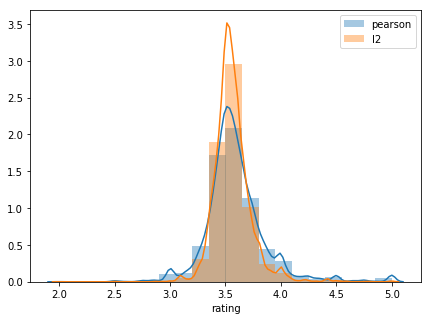

In [44]:
plt.figure(figsize=(7, 5))
sns.distplot(pearson_recs['rating'], bins=20,
             label='pearson', norm_hist=True)
sns.distplot(l2_recs['rating'], bins=20,
             label='l2', norm_hist=True)
plt.legend()
plt.show()

The distribution obtained using the correlation coefficient certainly has fatter tails